# Fuzzy Support Vector Machine (FSVM) Implementation

## Cel laboratorium
Implementacja Fuzzy SVM w oparciu o artykuł "Fuzzy Support Vector Machines" oraz porównanie wyników z klasycznym SVM.

### Teoria Fuzzy SVM
Fuzzy SVM rozszerza klasyczny SVM poprzez przypisanie każdemu punktowi treningowemu wartości przynależności (membership value) **s_i ∈ (0, 1]**. Ta wartość określa "ważność" punktu w procesie uczenia:
- Punkty z wysoką przynależnością (bliskie 1) mają większy wpływ na hyperplane
- Punkty z niską przynależnością (bliskie 0) - prawdopodobne outliers - mają mniejszy wpływ

### Modyfikacja funkcji celu
Klasyczny SVM:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n \xi_i$$

Fuzzy SVM:
$$\min_{w,b,\xi} \frac{1}{2}\|w\|^2 + C\sum_{i=1}^n s_i\xi_i$$

gdzie **s_i** to fuzzy membership value.

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_moons, make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.spatial.distance import cdist
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')
from sklearn.datasets import make_classification
from sklearn.datasets import make_moons
import time
from sklearn.svm import SVC

# Ustawienia wizualizacji
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

### Fuzzy SVM:

In [63]:
from sklearn.svm import SVC

class FuzzySVM:
    def __init__(self, kernel='rbf', membership='distance', C=1.0, gamma='scale', 
                 positive_weight=1.0, negative_weight=1.0):
        self.model = SVC(kernel=kernel, C=C, gamma=gamma, probability=True)
        self.membership_type = membership
        self.positive_weight = positive_weight
        self.negative_weight = negative_weight

    def compute_distance_membership(self, X, y):
        memberships = np.ones(len(X))
        classes = np.unique(y)
        for c in classes:
            class_mask = (y == c)
            X_class = X[class_mask]
            
            centroid = np.mean(X_class, axis=0)
            
            distances = np.linalg.norm(X_class - centroid, axis=1)
            
            max_dist = np.max(distances) if np.max(distances) > 0 else 1.0
            memberships[class_mask] = 1.0 - (distances / max_dist) * 0.9 + 0.1    
        return memberships
    
    
    def compute_sequential_membership(self, X, y, decay_factor=0.9):
        n_samples = len(X)
        memberships = np.zeros(n_samples)
        for i in range(n_samples):
            position_from_end = n_samples - 1 - i
            memberships[i] = decay_factor ** position_from_end
        
        memberships = memberships * 0.9 + 0.1
        
        return memberships
    
    def compute_class_weight_membership(self, X, y):
        """
        Membership bazująca na wagach klas.
        Używa wag przekazanych w konstruktorze (positive_weight, negative_weight).
        Przydatne dla imbalanced datasets lub gdy chcemy różnicować wpływ klas.
        """
        memberships = np.where(y == 1, self.positive_weight, self.negative_weight)
        return memberships

    def fit(self, X, y):
        if self.membership_type == 'distance':
            sample_weights = self.compute_distance_membership(X, y)
        elif self.membership_type == 'sequential':
            sample_weights = self.compute_sequential_membership(X, y)
        elif self.membership_type == 'class_weight':
            sample_weights = self.compute_class_weight_membership(X, y)
        else:
            raise ValueError(f"Unknown membership type: {self.membership_type}")
        
        self.model.fit(X, y, sample_weight=sample_weights)

    def predict(self, X):
        return self.model.predict(X)


### Testy obu SVM:

In [64]:
def generate_data(n_samples, n_features, random_state):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=random_state
    )
    y = 2 * y - 1
    return X, y

def generate_moons(n_samples, random_state):
    X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=random_state)
    y_moons = 2 * y_moons - 1
    return X_moons, y_moons

def generate_noisy_data(n_samples=500, outlier_fraction=0.1, noise=0.1, random_state=42):
    rng = np.random.RandomState(random_state)
    
    # Krok 1: Generujemy główne dane (np. dwa księżyce – nieliniowo separowalne)
    n_main = n_samples - int(n_samples * outlier_fraction)
    X_main, y_main = make_moons(n_samples=n_main, noise=noise, random_state=random_state)
    y_main = 2 * y_main - 1  # konwersja na +1/-1
    
    # Krok 2: Generujemy outliery
    n_outliers = n_samples - n_main
    
    # Outliery: losowe punkty daleko od chmur danych głównych
    # Umieszczamy je w losowych miejscach, ale z dala od centrum
    center = np.mean(X_main, axis=0)
    scale = np.max(np.std(X_main, axis=0)) * 5  # bardzo daleko
    
    X_outliers = center + scale * rng.uniform(-1, 1, size=(n_outliers, 2))
    
    # Przypisujemy outliery do losowej klasy (może być błędna!)
    y_outliers = rng.choice([-1, 1], size=n_outliers)
    
    # Krok 3: Łączymy dane
    X = np.vstack([X_main, X_outliers])
    y = np.hstack([y_main, y_outliers])
    
    # Krok 4: Mieszamy
    indices = np.arange(n_samples)
    rng.shuffle(indices)
    X, y = X[indices], y[indices]
    
    # Opcjonalnie: standaryzacja (zalecana dla SVM)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    
    return X, y

In [65]:
from matplotlib.colors import ListedColormap
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_curve, auc

def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()


In [66]:
X, y = generate_noisy_data(n_samples=500, outlier_fraction=0.15, noise=0.15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Rozmiar zbioru treningowego: {X_train.shape[0]}")
print(f"Rozmiar zbioru testowego: {X_test.shape[0]}")
print(f"Rozkład klas w zbiorze treningowym: {np.bincount(y_train + 1)}")
print(f"Rozkład klas w zbiorze testowym: {np.bincount(y_test + 1)}")

Rozmiar zbioru treningowego: 350
Rozmiar zbioru testowego: 150
Rozkład klas w zbiorze treningowym: [170   0 180]
Rozkład klas w zbiorze testowym: [78  0 72]


### Test 1: Klasyczny SVM (sklearn)

TEST KLASYCZNEGO SVM
Klasyczny SVM (sklearn) na Noisy Data:
Skuteczność: 86.0000%
Czułość (Recall): 83.3333%
Swoistość: 88.4615%
ROC AUC: 0.8590


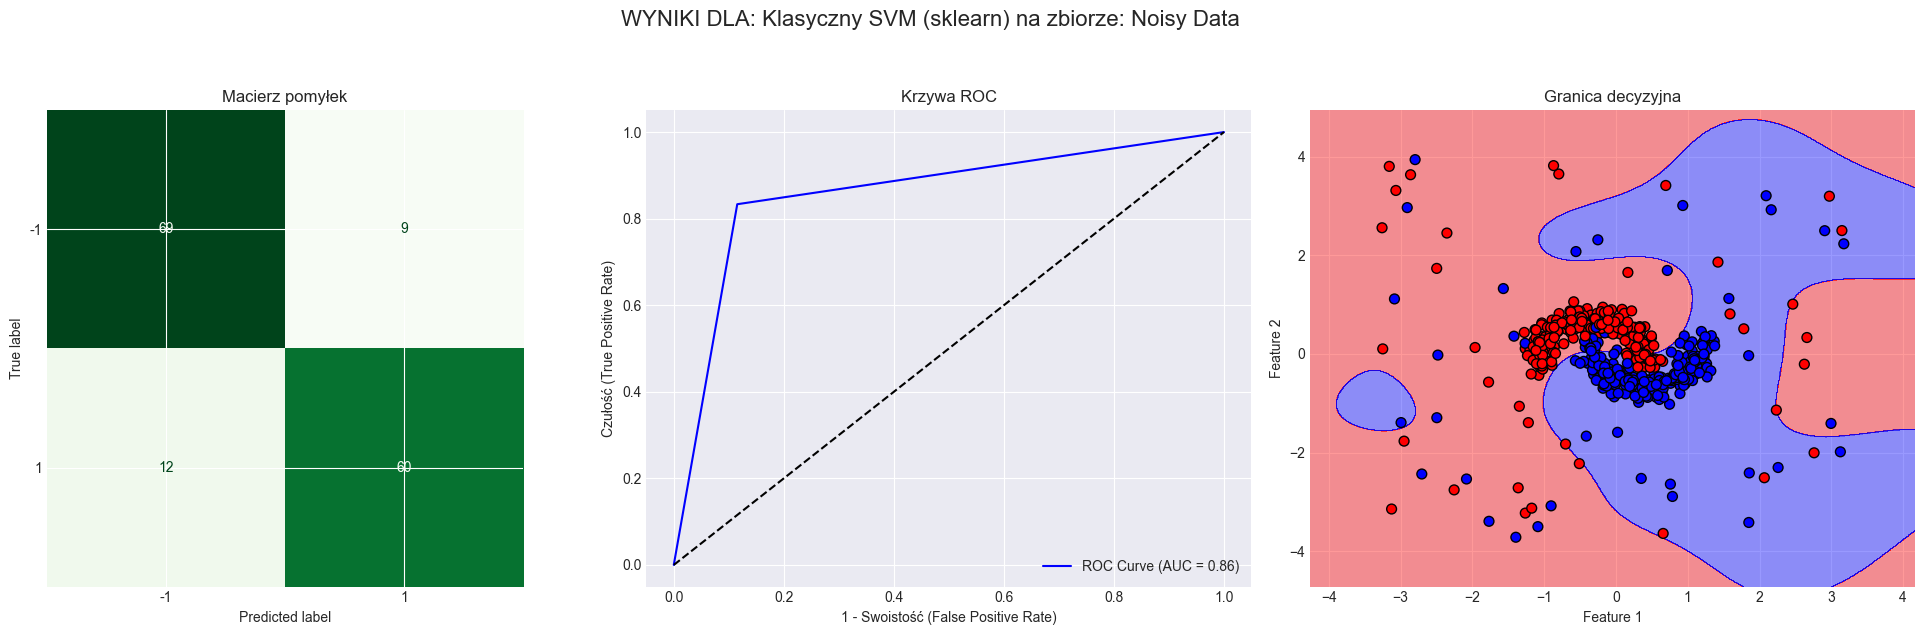

In [67]:
# 2. Test klasycznego SVM
print("=" * 60)
print("TEST KLASYCZNEGO SVM")
print("=" * 60)

svm_classic = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_classic.fit(X_train, y_train)
svm_pred = svm_classic.predict(X_test)

evaluate_classifier(y_test, svm_pred, X, y, svm_classic, 
                   "Klasyczny SVM (sklearn)", "Noisy Data", [-1, 1])

### Test 2: Fuzzy SVM z membership 'distance'


TEST FUZZY SVM - DISTANCE MEMBERSHIP
Fuzzy SVM (distance) na Noisy Data:
Skuteczność: 87.3333%
Czułość (Recall): 86.1111%
Swoistość: 88.4615%
ROC AUC: 0.8729


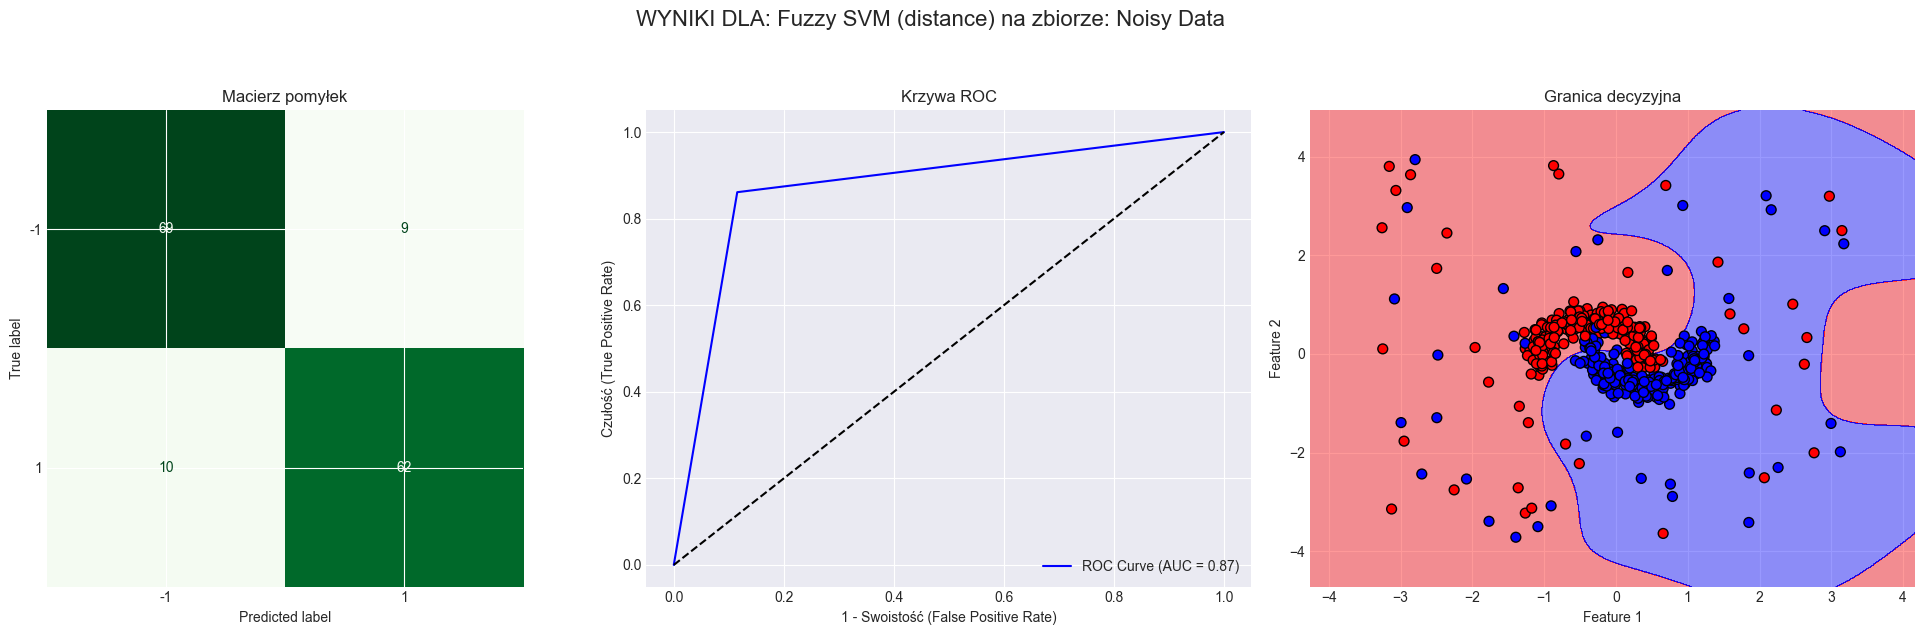

In [68]:
# 3. Test Fuzzy SVM z membership 'distance'
print("\n" + "=" * 60)
print("TEST FUZZY SVM - DISTANCE MEMBERSHIP")
print("=" * 60)

fuzzy_svm_distance = FuzzySVM(kernel='rbf', membership='distance', C=1.0, gamma='scale')
fuzzy_svm_distance.fit(X_train, y_train)
fuzzy_pred_distance = fuzzy_svm_distance.predict(X_test)

evaluate_classifier(y_test, fuzzy_pred_distance, X, y, fuzzy_svm_distance,
                   "Fuzzy SVM (distance)", "Noisy Data", [-1, 1])

### Test 3: Fuzzy SVM z membership 'sequential'


TEST FUZZY SVM - SEQUENTIAL MEMBERSHIP
Fuzzy SVM (sequential) na Noisy Data:
Skuteczność: 82.6667%
Czułość (Recall): 77.7778%
Swoistość: 87.1795%
ROC AUC: 0.8248


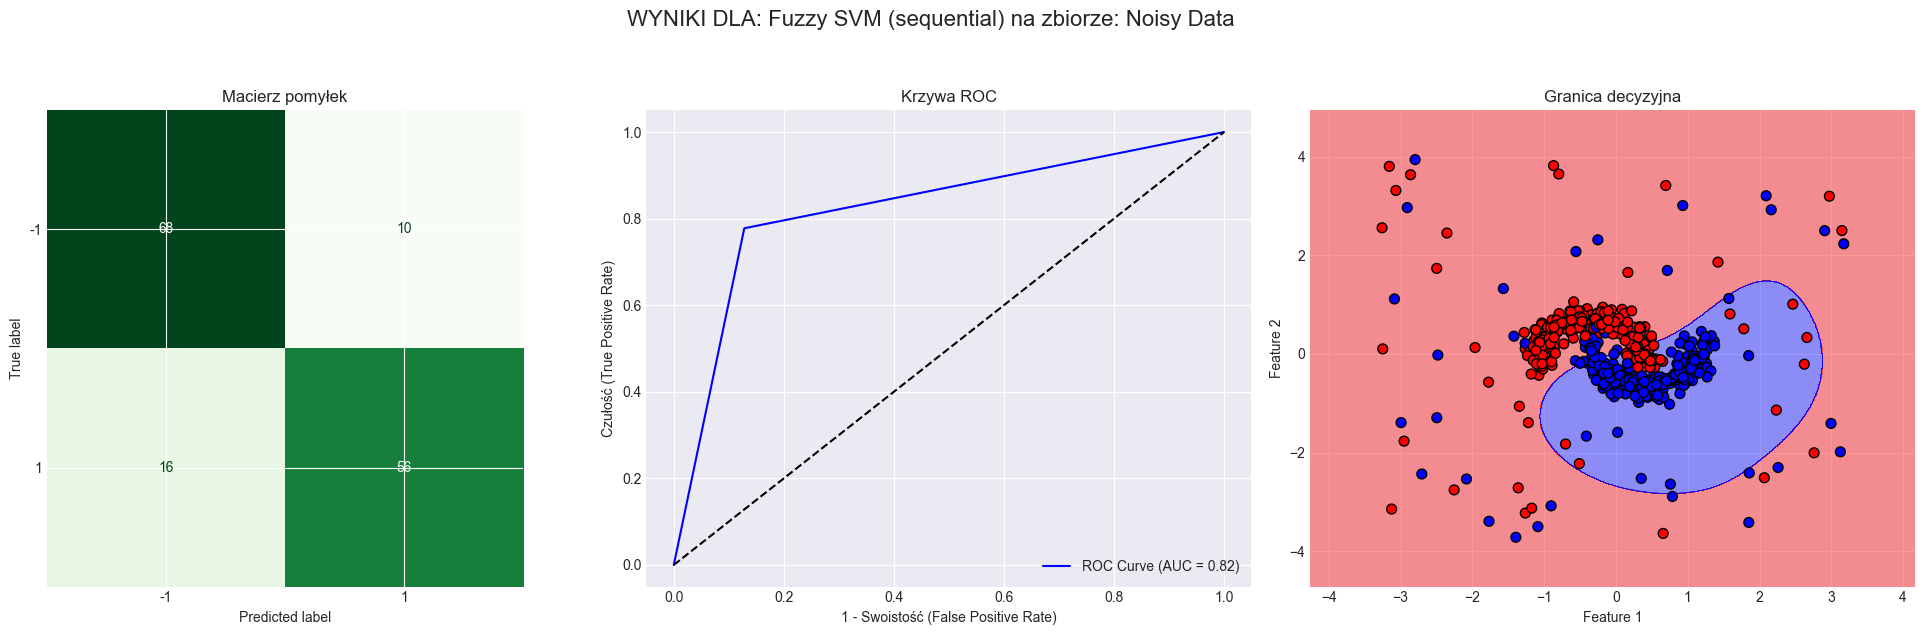

In [69]:
# Test Fuzzy SVM z membership 'sequential'
print("\n" + "=" * 60)
print("TEST FUZZY SVM - SEQUENTIAL MEMBERSHIP")
print("=" * 60)

fuzzy_svm_sequential = FuzzySVM(kernel='rbf', membership='sequential', C=1.0, gamma='scale')
fuzzy_svm_sequential.fit(X_train, y_train)
fuzzy_pred_sequential = fuzzy_svm_sequential.predict(X_test)

evaluate_classifier(y_test, fuzzy_pred_sequential, X, y, fuzzy_svm_sequential,
                   "Fuzzy SVM (sequential)", "Noisy Data", [-1, 1])

### Porównanie wyników

In [70]:
# Porównanie wszystkich modeli
print("\n" + "=" * 60)
print("PODSUMOWANIE - PORÓWNANIE WSZYSTKICH MODELI")
print("=" * 60)

models = {
    "Klasyczny SVM": svm_pred,
    "Fuzzy SVM (distance)": fuzzy_pred_distance,
    "Fuzzy SVM (sequential)": fuzzy_pred_sequential,
}

results = []
for name, predictions in models.items():
    acc = accuracy_score(y_test, predictions)
    cm = confusion_matrix(y_test, predictions)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    results.append({
        'Model': name,
        'Accuracy': f"{acc*100:.2f}%",
        'Sensitivity': f"{sensitivity*100:.2f}%",
        'Specificity': f"{specificity*100:.2f}%"
    })

import pandas as pd
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))


PODSUMOWANIE - PORÓWNANIE WSZYSTKICH MODELI
                 Model Accuracy Sensitivity Specificity
         Klasyczny SVM   86.00%      83.33%      88.46%
  Fuzzy SVM (distance)   87.33%      86.11%      88.46%
Fuzzy SVM (sequential)   82.67%      77.78%      87.18%


### Test różnych wag dla class_weight

In [71]:
print("\n" + "=" * 60)
print("EKSPERYMENTY Z RÓŻNYMI WAGAMI CLASS_WEIGHT")
print("=" * 60)

weight_configs = [
    (1.0, 1.0, "Równe wagi"),
    (1.0, 0.5, "Favoryzacja klasy +1"),
    (0.5, 1.0, "Favoryzacja klasy -1"),
    (1.0, 0.3, "Silna favoryzacja klasy +1"),
    (0.3, 1.0, "Silna favoryzacja klasy -1"),
]

weight_results = []
for pos_w, neg_w, desc in weight_configs:
    fuzzy = FuzzySVM(kernel='rbf', membership='class_weight', C=1.0, gamma='scale',
                     positive_weight=pos_w, negative_weight=neg_w)
    fuzzy.fit(X_train, y_train)
    pred = fuzzy.predict(X_test)
    acc = accuracy_score(y_test, pred)
    
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    weight_results.append({
        'Konfiguracja': desc,
        'Wagi (+1/-1)': f"{pos_w}/{neg_w}",
        'Accuracy': f"{acc*100:.2f}%",
        'Sensitivity': f"{sensitivity*100:.2f}%",
        'Specificity': f"{specificity*100:.2f}%"
    })
    
df_weights = pd.DataFrame(weight_results)
print(df_weights.to_string(index=False))


EKSPERYMENTY Z RÓŻNYMI WAGAMI CLASS_WEIGHT
              Konfiguracja Wagi (+1/-1) Accuracy Sensitivity Specificity
                Równe wagi      1.0/1.0   86.00%      83.33%      88.46%
      Favoryzacja klasy +1      1.0/0.5   85.33%      93.06%      78.21%
      Favoryzacja klasy -1      0.5/1.0   86.67%      76.39%      96.15%
Silna favoryzacja klasy +1      1.0/0.3   82.00%      97.22%      67.95%
Silna favoryzacja klasy -1      0.3/1.0   84.67%      68.06%     100.00%
